In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Loading the Dataset
df = pd.read_csv("synthetic_student_burnout_data.csv")
df.head()

,student_id,week,avg_submission_delay,quiz_score,attendance_pct,study_sessions,deadline_load,burnout_risk
0,1,1,0.58,73.48,89.53,4,1,0
1,1,2,0.34,70.41,85.54,4,1,0
2,1,3,0.00,71.85,90.52,5,3,0
3,1,4,0.45,70.01,91.17,4,3,0
4,1,5,0.63,72.77,90.40,4,2,0


In [3]:
df.shape

(4800, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4800 entries, 0 to 4799
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            4800 non-null   int64  
 1   week                  4800 non-null   int64  
 2   avg_submission_delay  4800 non-null   float64
 3   quiz_score            4800 non-null   float64
 4   attendance_pct        4800 non-null   float64
 5   study_sessions        4800 non-null   int64  
 6   deadline_load         4800 non-null   int64  
 7   burnout_risk          4800 non-null   int64  
dtypes: float64(3), int64(5)
memory usage: 300.1 KB


In [5]:
df.isnull().sum()

student_id              0
week                    0
avg_submission_delay    0
quiz_score              0
attendance_pct          0
study_sessions          0
deadline_load           0
burnout_risk            0
dtype: int64

In [6]:
df.describe()

,student_id,week,avg_submission_delay,quiz_score,attendance_pct,study_sessions,deadline_load,burnout_risk
count,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000
mean,200.500000,6.500000,1.143915,73.254592,88.627081,4.018125,1.995417,0.325000
std,115.481723,3.452412,1.018975,7.278526,5.695673,1.634529,0.815036,0.468424
min,1.000000,1.000000,0.000000,41.590000,61.820000,1.000000,1.000000,0.000000
25%,100.750000,3.750000,0.390000,68.680000,84.980000,3.000000,1.000000,0.000000
50%,200.500000,6.500000,0.690000,73.505000,88.850000,4.000000,2.000000,0.000000
75%,300.250000,9.250000,1.950000,78.030000,92.630000,5.000000,3.000000,1.000000
max,400.000000,12.000000,4.550000,99.290000,100.000000,6.000000,3.000000,1.000000


In [7]:
df["burnout_risk"].value_counts()

burnout_risk
0    3240
1    1560
Name: count, dtype: int64

In [8]:
df["burnout_risk"].value_counts(normalize=True)

burnout_risk
0    0.675
1    0.325
Name: proportion, dtype: float64

# Visualisations

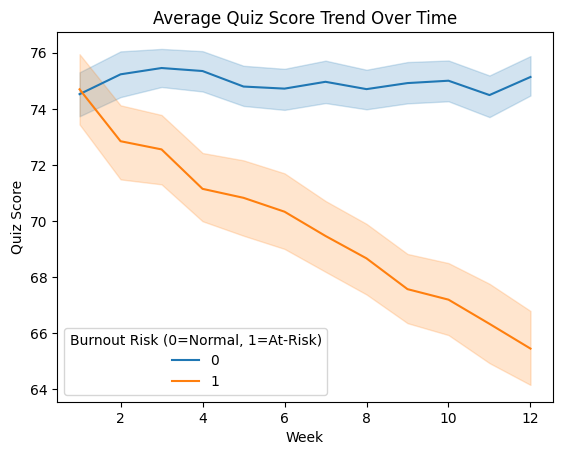

In [10]:
sns.lineplot(
    data=df,
    x="week",
    y="quiz_score",
    hue="burnout_risk",
    estimator="mean"
)

plt.title("Average Quiz Score Trend Over Time")
plt.xlabel("Week")
plt.ylabel("Quiz Score")
plt.legend(title="Burnout Risk (0=Normal, 1=At-Risk)")
plt.show()

The plot shows a clear divergence in quiz score trends between normal and at-risk students. While normal students maintain stable performance throughout the semester, at-risk students exhibit a steady decline in average quiz scores, indicating that performance deterioration over time is a strong signal of academic burnout.

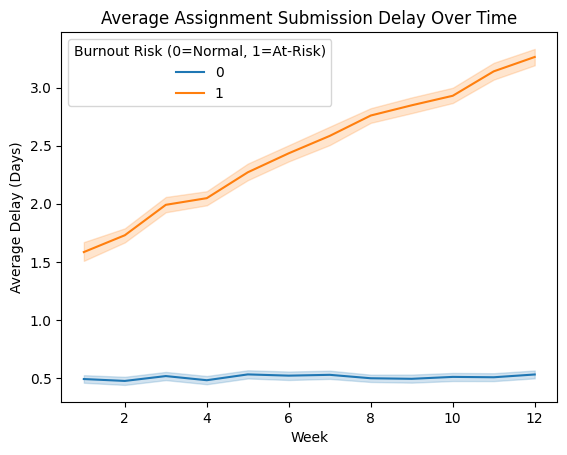

In [12]:
sns.lineplot(
    data=df,
    x="week",
    y="avg_submission_delay",
    hue="burnout_risk",
    estimator="mean"
)

plt.title("Average Assignment Submission Delay Over Time")
plt.xlabel("Week")
plt.ylabel("Average Delay (Days)")
plt.legend(title="Burnout Risk (0=Normal, 1=At-Risk)")
plt.show()

The average assignment submission delay for at-risk students increases steadily over time, while normal students maintain consistently low delays. This suggests that growing difficulty in meeting deadlines is a strong behavioral indicator of academic burnout.

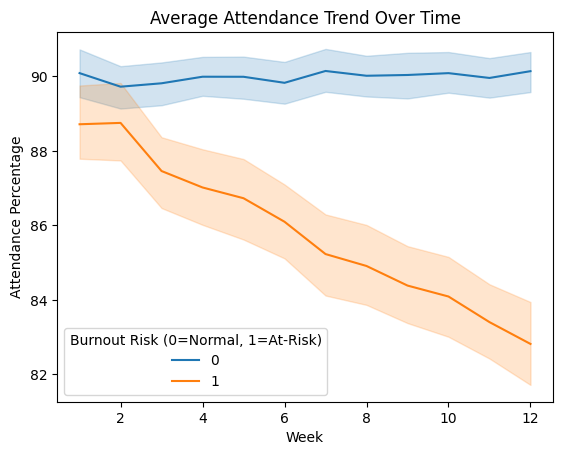

In [14]:
sns.lineplot(
    data=df,
    x="week",
    y="attendance_pct",
    hue="burnout_risk",
    estimator="mean"
)

plt.title("Average Attendance Trend Over Time")
plt.xlabel("Week")
plt.ylabel("Attendance Percentage")
plt.legend(title="Burnout Risk (0=Normal, 1=At-Risk)")
plt.show()

The attendance trend shows a gradual decline for at-risk students, while normal students maintain consistently high attendance. This suggests reduced academic engagement over time among students experiencing burnout.

# Feature Enginnering

Raw weekly values capture isolated snapshots of student behavior but do not reflect how that behavior is changing over time. Trend-based and rolling features help capture the direction, momentum, and stability of academic behavior, which are critical for identifying gradual burnout patterns.

In [18]:
df = df.sort_values(by=["student_id", "week"]).reset_index(drop=True)
df.head()

,student_id,week,avg_submission_delay,quiz_score,attendance_pct,study_sessions,deadline_load,burnout_risk
0,1,1,0.58,73.48,89.53,4,1,0
1,1,2,0.34,70.41,85.54,4,1,0
2,1,3,0.00,71.85,90.52,5,3,0
3,1,4,0.45,70.01,91.17,4,3,0
4,1,5,0.63,72.77,90.40,4,2,0


In [19]:
df["quiz_avg_3w"] = (
    df.groupby("student_id")["quiz_score"]
      .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

df[["student_id", "week", "quiz_score", "quiz_avg_3w"]].head(10)

,student_id,week,quiz_score,quiz_avg_3w
0,1,1,73.48,73.480000
1,1,2,70.41,71.945000
2,1,3,71.85,71.913333
3,1,4,70.01,70.756667
4,1,5,72.77,71.543333
5,1,6,67.04,69.940000
6,1,7,76.85,72.220000
7,1,8,68.52,70.803333
8,1,9,74.22,73.196667
9,1,10,65.40,69.380000


In [20]:
df["delay_avg_3w"] = (
    df.groupby("student_id")["avg_submission_delay"]
      .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

df[["student_id", "week", "avg_submission_delay", "delay_avg_3w"]].head(10)

,student_id,week,avg_submission_delay,delay_avg_3w
0,1,1,0.58,0.580000
1,1,2,0.34,0.460000
2,1,3,0.00,0.306667
3,1,4,0.45,0.263333
4,1,5,0.63,0.360000
5,1,6,0.49,0.523333
6,1,7,0.32,0.480000
7,1,8,0.18,0.330000
8,1,9,1.33,0.610000
9,1,10,0.76,0.756667


In [21]:
df["attendance_avg_3w"] = (
    df.groupby("student_id")["attendance_pct"]
      .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

df[["student_id", "week", "attendance_pct", "attendance_avg_3w"]].head(10)

,student_id,week,attendance_pct,attendance_avg_3w
0,1,1,89.53,89.530000
1,1,2,85.54,87.535000
2,1,3,90.52,88.530000
3,1,4,91.17,89.076667
4,1,5,90.40,90.696667
5,1,6,94.12,91.896667
6,1,7,91.24,91.920000
7,1,8,92.44,92.600000
8,1,9,91.93,91.870000
9,1,10,86.53,90.300000


In [22]:
df["quiz_trend"] = (
    df.groupby("student_id")["quiz_score"]
      .diff()
      .fillna(0)
)

df[["student_id", "week", "quiz_score", "quiz_trend"]].head(10)

,student_id,week,quiz_score,quiz_trend
0,1,1,73.48,0.00
1,1,2,70.41,-3.07
2,1,3,71.85,1.44
3,1,4,70.01,-1.84
4,1,5,72.77,2.76
5,1,6,67.04,-5.73
6,1,7,76.85,9.81
7,1,8,68.52,-8.33
8,1,9,74.22,5.70
9,1,10,65.40,-8.82


In [23]:
df["attendance_trend"] = (
    df.groupby("student_id")["attendance_pct"]
      .diff()
      .fillna(0)
)

df[["student_id", "week", "attendance_pct", "attendance_trend"]].head(10)

,student_id,week,attendance_pct,attendance_trend
0,1,1,89.53,0.00
1,1,2,85.54,-3.99
2,1,3,90.52,4.98
3,1,4,91.17,0.65
4,1,5,90.40,-0.77
5,1,6,94.12,3.72
6,1,7,91.24,-2.88
7,1,8,92.44,1.20
8,1,9,91.93,-0.51
9,1,10,86.53,-5.40


In [24]:
df["quiz_std_3w"] = (
    df.groupby("student_id")["quiz_score"]
      .transform(lambda x: x.rolling(window=3, min_periods=1).std())
      .fillna(0)
)

df[["student_id", "week", "quiz_score", "quiz_std_3w"]].head(10)

,student_id,week,quiz_score,quiz_std_3w
0,1,1,73.48,0.000000
1,1,2,70.41,2.170818
2,1,3,71.85,1.535980
3,1,4,70.01,0.967747
4,1,5,72.77,1.405323
5,1,6,67.04,2.865641
6,1,7,76.85,4.928073
7,1,8,68.52,5.288595
8,1,9,74.22,4.258243
9,1,10,65.40,4.472449


In [25]:
feature_cols = [
    "quiz_avg_3w",
    "delay_avg_3w",
    "attendance_avg_3w",
    "quiz_trend",
    "attendance_trend",
    "quiz_std_3w",
    "study_sessions",
    "deadline_load"
]

X = df[feature_cols]
y = df["burnout_risk"]

X.head(), y.head()

(   quiz_avg_3w  delay_avg_3w  attendance_avg_3w  quiz_trend  attendance_trend  \
 0    73.480000      0.580000          89.530000        0.00              0.00   
 1    71.945000      0.460000          87.535000       -3.07             -3.99   
 2    71.913333      0.306667          88.530000        1.44              4.98   
 3    70.756667      0.263333          89.076667       -1.84              0.65   
 4    71.543333      0.360000          90.696667        2.76             -0.77   
 
    quiz_std_3w  study_sessions  deadline_load  
 0     0.000000               4              1  
 1     2.170818               4              1  
 2     1.535980               5              3  
 3     0.967747               4              3  
 4     1.405323               4              2  ,
 0    0
 1    0
 2    0
 3    0
 4    0
 Name: burnout_risk, dtype: int64)

# Building Classification Model

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

X_train.shape, X_test.shape

((3840, 8), (960, 8))

In [29]:
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(burnout_risk
 0    0.675
 1    0.325
 Name: proportion, dtype: float64,
 burnout_risk
 0    0.675
 1    0.325
 Name: proportion, dtype: float64)

In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [32]:
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

In [33]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_lr)

array([[648,   0],
       [  1, 311]])

In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       648
           1       1.00      1.00      1.00       312

    accuracy                           1.00       960
   macro avg       1.00      1.00      1.00       960
weighted avg       1.00      1.00      1.00       960



In [35]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_clf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
y_pred_rf = rf_clf.predict(X_test)
y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]

In [37]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_rf)

array([[648,   0],
       [  0, 312]])

In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       648
           1       1.00      1.00      1.00       312

    accuracy                           1.00       960
   macro avg       1.00      1.00      1.00       960
weighted avg       1.00      1.00      1.00       960



In [39]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_clf.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
1,delay_avg_3w,0.466030
6,study_sessions,0.455560
0,quiz_avg_3w,0.031938
2,attendance_avg_3w,0.027979
5,quiz_std_3w,0.008685
4,attendance_trend,0.007461
3,quiz_trend,0.002053
7,deadline_load,0.000295


In [40]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import recall_score, make_scorer

recall_scorer = make_scorer(recall_score, pos_label=1)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_recall = cross_val_score(
    rf_clf,
    X,
    y,
    cv=skf,
    scoring=recall_scorer
)

cv_recall, cv_recall.mean()

(array([1., 1., 1., 1., 1.]), 1.0)

# Building Regression Model

Linear Regression was used as a baseline to predict next-week quiz scores. Model performance is evaluated using MAE and RMSE, which reflect average and large prediction errors respectively.

In [43]:
df["quiz_score_next_week"] = (
    df.groupby("student_id")["quiz_score"].shift(-1)
)

df[["student_id", "week", "quiz_score", "quiz_score_next_week"]].head(12)

,student_id,week,quiz_score,quiz_score_next_week
0,1,1,73.48,70.41
1,1,2,70.41,71.85
2,1,3,71.85,70.01
3,1,4,70.01,72.77
4,1,5,72.77,67.04
5,1,6,67.04,76.85
6,1,7,76.85,68.52
7,1,8,68.52,74.22
8,1,9,74.22,65.40
9,1,10,65.40,73.67


In [44]:
reg_df = df.dropna(subset=["quiz_score_next_week"]).copy()

reg_df.shape

(4400, 15)

In [45]:
y_reg = reg_df["quiz_score_next_week"]

reg_feature_cols = [
    "quiz_avg_3w",
    "delay_avg_3w",
    "attendance_avg_3w",
    "quiz_trend",
    "attendance_trend",
    "quiz_std_3w",
    "study_sessions",
    "deadline_load"
]

X_reg = reg_df[reg_feature_cols]

In [46]:
X_reg.head(), y_reg.head()

(   quiz_avg_3w  delay_avg_3w  attendance_avg_3w  quiz_trend  attendance_trend  \
 0    73.480000      0.580000          89.530000        0.00              0.00   
 1    71.945000      0.460000          87.535000       -3.07             -3.99   
 2    71.913333      0.306667          88.530000        1.44              4.98   
 3    70.756667      0.263333          89.076667       -1.84              0.65   
 4    71.543333      0.360000          90.696667        2.76             -0.77   
 
    quiz_std_3w  study_sessions  deadline_load  
 0     0.000000               4              1  
 1     2.170818               4              1  
 2     1.535980               5              3  
 3     0.967747               4              3  
 4     1.405323               4              2  ,
 0    70.41
 1    71.85
 2    70.01
 3    72.77
 4    67.04
 Name: quiz_score_next_week, dtype: float64)

In [47]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split( X_reg,y_reg,test_size=0.2,random_state=42)

Xr_train.shape, Xr_test.shape

((3520, 8), (880, 8))

In [48]:
scaler_reg = StandardScaler()

Xr_train_scaled = scaler_reg.fit_transform(Xr_train)
Xr_test_scaled = scaler_reg.transform(Xr_test)

In [49]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

lin_reg.fit(Xr_train_scaled, yr_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [50]:
y_pred_reg = lin_reg.predict(Xr_test_scaled)

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(yr_test, y_pred_reg)
rmse = np.sqrt(mean_squared_error(yr_test, y_pred_reg))

mae, rmse

(3.8295282898694785, 4.87915543213941)

The regression model predicts next-week quiz scores with an average error of around 4 marks, which provides a reasonable estimate of performance decline severity rather than exact score prediction.

In [53]:
from sklearn.metrics import r2_score

r2_lr = r2_score(yr_test, y_pred_reg)
r2_lr

0.5408847996038089

In [54]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_reg.fit(Xr_train, yr_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_rf_reg = rf_reg.predict(Xr_test)

mae_rf = mean_absolute_error(yr_test, y_pred_rf_reg)
rmse_rf = np.sqrt(mean_squared_error(yr_test, y_pred_rf_reg))
r2_rf = r2_score(yr_test, y_pred_rf_reg)

mae_rf, rmse_rf, r2_rf

(3.940471704545453, 5.032107189067155, 0.5116489432890872)

We evaluated both linear and non-linear regression models. Linear Regression achieved slightly lower prediction error, suggesting that short-term performance decline is largely linearly related to recent behavioral patterns.

In [57]:
from sklearn.ensemble import RandomForestClassifier

rf_limited = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)

rf_limited.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [58]:
y_pred_limited = rf_limited.predict(X_test)
y_prob_limited = rf_limited.predict_proba(X_test)[:, 1]

In [59]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_limited)

array([[647,   1],
       [  0, 312]])

In [60]:
from sklearn.metrics import roc_auc_score

roc_auc_limited = roc_auc_score(y_test, y_prob_limited)
roc_auc_limited

1.0

Even after constraining the Random Forest to shallow trees, the model maintains perfect ROC-AUC and zero false negatives. This indicates that the behavioral features are inherently discriminative, not overfitted

# Using SHAP

While the classification models demonstrate very strong predictive performance, accurate predictions alone are not sufficient for sensitive applications such as academic burnout detection. It is important to understand *why* a student is flagged as at risk, not just *that* they are flagged.

To address this, SHAP (SHapley Additive exPlanations) is used to interpret the Random Forest classifier. SHAP provides both global and local explanations by quantifying the contribution of each behavioral feature to the model’s predictions. This improves transparency, supports trust in the model, and enables actionable insights for early intervention.

In [64]:
!pip install shap

In [65]:
!pip install "numpy<2.0"

In [66]:
!pip uninstall shap -y

Found existing installation: shap 0.44.1
Uninstalling shap-0.44.1:
  Successfully uninstalled shap-0.44.1


In [67]:
!pip install shap==0.44.1

  Using cached shap-0.44.1-cp312-cp312-macosx_11_0_arm64.whl


In [68]:
import numpy as np
import shap

np.__version__, shap.__version__

('1.26.4', '0.44.1')

In [69]:
# Build SHAP explainer for Random Forest classifier
explainer = shap.TreeExplainer(rf_clf)

In [70]:
# Compute SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# For binary classification, take SHAP values for class 1 (at-risk)
shap_values_at_risk = shap_values[1]

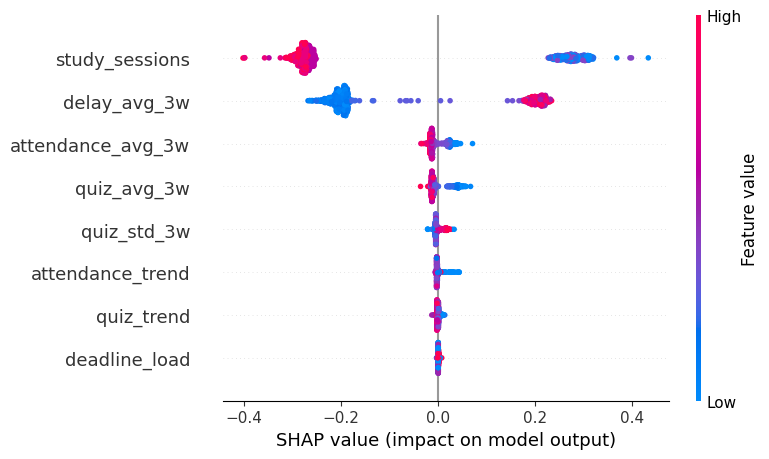

In [71]:
# Global SHAP summary plot
shap.summary_plot(
    shap_values_at_risk,
    X_test,
    feature_names=feature_cols,
    show=True
)

**Interpretation:**  
The SHAP analysis confirms that behavioral consistency matters more than raw performance. Persistent assignment delays and irregular study effort are the strongest indicators of burnout risk, while stable attendance and steady academic performance act as protective factors.

In [73]:
# Find first at-risk student in test set
at_risk_index = y_test[y_test == 1].index[0]

X_student = X_test.loc[[at_risk_index]]
X_student

,quiz_avg_3w,delay_avg_3w,attendance_avg_3w,quiz_trend,attendance_trend,quiz_std_3w,study_sessions,deadline_load
4119,64.076667,1.7,84.413333,-7.85,-4.92,7.103565,3,1


**Local Explanation:**  
The model classified this student as at risk primarily due to persistent assignment delays, declining quiz performance, and reduced attendance over recent weeks. Although the workload remained moderate, behavioral disengagement and performance instability outweighed protective factors, indicating an early stage of academic burnout that may benefit from timely intervention.

## Risk Stratification

While the classification model predicts burnout risk as a binary outcome, prediction probabilities are further used to stratify students into Low, Medium, and High risk categories. This post-processing step improves interpretability and supports severity-aware intervention planning without modifying the underlying model.


In [76]:
def stratify_risk(burnout_probability):
    if burnout_probability < 0.30:
        return "Low Risk"
    elif burnout_probability < 0.60:
        return "Medium Risk"
    else:
        return "High Risk"

In [77]:
# Get probability for one student
student_prob = rf_clf.predict_proba(X_student)[0][1]

risk_level = stratify_risk(student_prob)

student_prob, risk_level

(1.0, 'High Risk')

## Intervention Recommendation Layer

After identifying burnout risk and stratifying severity levels, a rule-based intervention layer is applied to translate model insights into actionable academic support recommendations. This layer does not automate decisions; instead, it provides human-interpretable guidance based on dominant behavioral risk patterns.

In [79]:
def recommend_interventions(student_row, risk_level):
    recommendations = []

    # High risk interventions
    if risk_level == "High Risk":
        if student_row["delay_avg_3w"] > 1.5:
            recommendations.append(
                "Time management support: assist with deadline planning and task prioritization."
            )
        if student_row["study_sessions"] < 3 or student_row["study_sessions"] > 6:
            recommendations.append(
                "Study routine stabilization: establish a consistent and balanced study schedule."
            )
        if student_row["attendance_avg_3w"] < 85 or student_row["attendance_trend"] < -3:
            recommendations.append(
                "Academic engagement support: recommend faculty or mentor check-in."
            )
        if student_row["quiz_avg_3w"] < 65 or student_row["quiz_trend"] < -5:
            recommendations.append(
                "Performance recovery support: provide subject-specific academic assistance."
            )

    # Medium risk interventions
    elif risk_level == "Medium Risk":
        recommendations.append(
            "Preventive guidance: monitor trends and encourage structured study habits."
        )

    # Low risk interventions
    else:
        recommendations.append(
            "Monitoring only: no immediate intervention required."
        )

    return recommendations

In [80]:
# Example student (already selected earlier)
student_example = X_student

# Get probability and risk level
student_prob = rf_clf.predict_proba(student_example)[0][1]
risk_level = stratify_risk(student_prob)

# Get recommendations
recommendations = recommend_interventions(student_example.iloc[0], risk_level)

student_prob, risk_level, recommendations

(1.0,
 'High Risk',
 ['Time management support: assist with deadline planning and task prioritization.',
  'Academic engagement support: recommend faculty or mentor check-in.',
  'Performance recovery support: provide subject-specific academic assistance.'])

**Intervention Output:**  
Based on the identified risk level and dominant behavioral patterns, the system suggests targeted academic support actions. These recommendations are advisory and intended to assist educators or mentors in planning timely, human-led interventions.

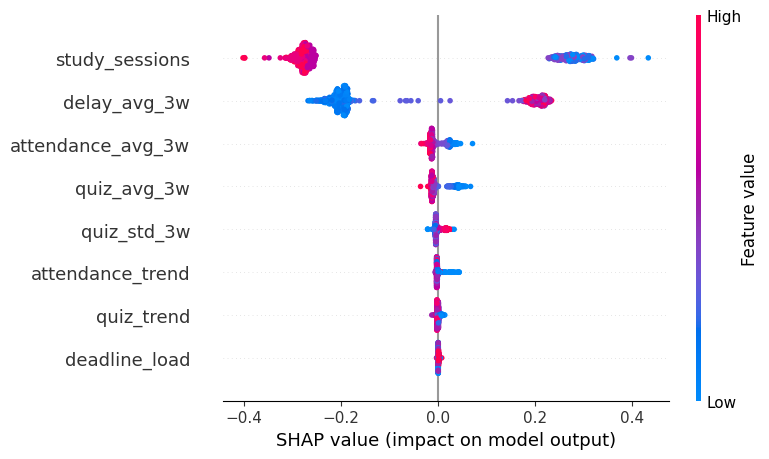

In [82]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values_at_risk,
    X_test,
    feature_names=feature_cols,
    show=False
)

plt.tight_layout()
plt.savefig("shap_global_summary.png", dpi=300, bbox_inches="tight")
plt.show()

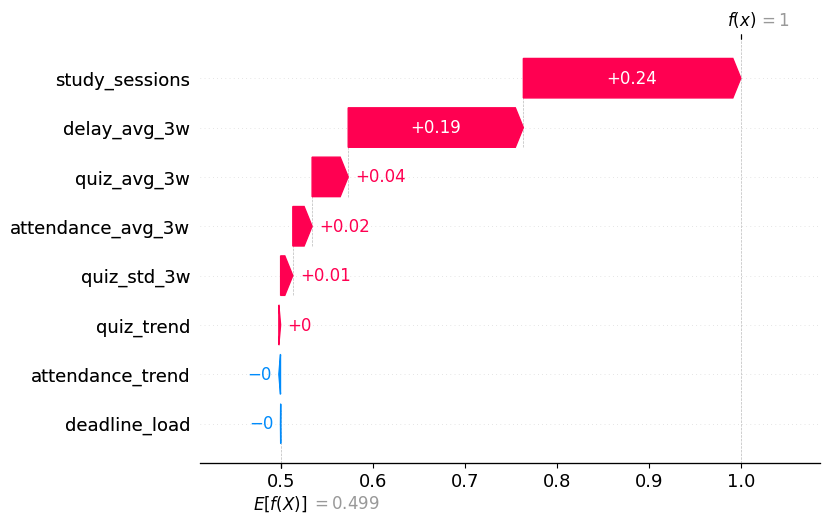

In [94]:
X_student = X_test.iloc[[0]]
shap_values_student = explainer.shap_values(X_student)

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[1],          # base value for class 1
    shap_values_student[1][0],             # SINGLE explanation vector
    feature_names=feature_cols,
    show=False
)

plt.savefig("shap_local_explanation.png", dpi=300, bbox_inches="tight")
plt.show()

In [88]:
import pickle

with open("rf_clf.pkl", "wb") as f:
    pickle.dump(rf_clf, f)

with open("lin_reg.pkl", "wb") as f:
    pickle.dump(lin_reg, f)

with open("feature_cols.pkl", "wb") as f:
    pickle.dump(feature_cols, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ Final deployment artifacts saved.")

✅ Final deployment artifacts saved.
